<a href="https://colab.research.google.com/github/thiagolmetne/mvp_analise_de_dados_puc/blob/main/C%C3%B3pia_de_Dataset_MedalhasGPD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analise Exploratoria - README do Projeto de Análise de Dados de Vendas**

Notebook desenvolvido em atendimento ao MVP da Sprint Análise de Dados de Boas práticas
Este notebook contém uma análise exploratória de dados das medalhas olímpicas por delegação distribuídas por Renda per Capta do país no determinado ano, focada em entender se a renda da nação impacta na performance olímpica da mesma.
Objetivo Geral
O objetivo principal deste projeto é extrair insights acionáveis dos dados medalhas, respondendo a perguntas-chave sobre:

**GDP x Medalhas:** Como o ganho de medalhas de uma nação está relacionado a renda percapta dela, se existe correlação;

**Desenvolvimento Esportivo:** Houve relação entre o aumento de renda per capta das nações e seu aumento esportivo?

**Dentro das regiões há distinção de Renda per capta** Os continentes são impactados pela diferença de renda per capta também?


# Importação das Bibliotecas Necessárias

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização.

In [ ]:
import pandas as pd
from IPython.display import display # Importando a função display. Houve necessidade de importar pois
# como a renderização automática de tabelas em ambientes como Colab geralmente ocorre para a última saída de uma célula,
# a função display() força a renderização de um objeto (como um DataFrame) a qualquer momento,
#independentemente de ser a última linha da célula.
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Necessária para incluir o gráfico de linhas com os meses em português
import matplotlib.dates as mdates
import matplotlib.ticker as mticker  # Importa mticker para FuncFormatter

# Útil para Dividir dados em treino e teste (para treinar e avaliar o modelo)
from sklearn.model_selection import train_test_split

#Útil para o Escalonamento de Features Numéricas na etapa de pré-processamento
#Apenas "Age" como variável numérica direta
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Criação das funções

Esta seção consolida todas as funções necessárias para a análise, visualização e pré-processamento dos dados, bem como os parâmetros para sua utilização.

In [ ]:
def define_titulo_eixos(t,x,y):
    # Adiciona títulos e rótulos aos gráficos que serão criados
    # Parâmetros: Título do Gráfico, Rótulo do eixo X e Rótulo do eixo Y
    plt.title(t, fontsize=16)
    plt.xlabel(x, fontsize = 12)
    plt.ylabel(y, fontsize = 12)

def formatar_mes(x, pos):
    # x é o valor numérico da data no matplotlib (dias desde 0001-01-01)
    # Convertemos x para um objeto datetime
    data_dt = mdates.num2date(x)

    # Pegamos o número do mês (1 a 12) e ajustamos para o índice da lista (0 a 11)
    nome_mes = meses_portugues[data_dt.month - 1]

    # Pegamos o ano diretamente do objeto datetime
    ano = data_dt.year

    # Retornamos a string formatada como "Mês Ano"
    return f"{nome_mes}/{ano}"

def configurar_eixo_x_datas(ax, formatador_personalizado):
    #Configura o eixo X de um gráfico Matplotlib para exibir datas
    #   com localizadores de mês e um formatador personalizado.

    #   Parâmetros:
    #   ax : matplotlib.axes.Axes //O objeto Axes do Matplotlib ao qual as configurações serão aplicadas.
    #   formatador_personalizado : function //A função que será usada para formatar os rótulos do eixo X.
    #        Deve aceitar dois argumentos (valor numérico da data, posição do tick).

    # Define o localizador principal para ticks mensais
    ax.xaxis.set_major_locator(mdates.MonthLocator())

    # Aplica o formatador customizado ao eixo X
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatador_personalizado))

    # Rotaciona os rótulos para evitar sobreposição se houver muitos ticks
    plt.gcf().autofmt_xdate()

def finalizar_e_salvar_grafico(nome_arquivo):
    #Ajusta o layout do gráfico, salva em um arquivo e o exibe.
    #Argumentos: nome_arquivo (str): O nome do arquivo para salvar o gráfico.

    plt.tight_layout()  # Ajusta o layout para evitar sobreposição
    plt.savefig(nome_arquivo) # Salva o gráfico com o nome especificado
    plt.show() # Exibe o gráfico

## **Criação das funções**
Esta seção consolida todas as funções necessárias para a análise, visualização e pré-processamento dos dados, bem como os parâmetros para sua utilização.

In [ ]:
def define_titulo_eixos(t,x,y):
    # Adiciona títulos e rótulos aos gráficos que serão criados
    # Parâmetros: Título do Gráfico, Rótulo do eixo X e Rótulo do eixo Y
    plt.title(t, fontsize=16)
    plt.xlabel(x, fontsize = 12)
    plt.ylabel(y, fontsize = 12)

def formatar_mes(x, pos):
    # x é o valor numérico da data no matplotlib (dias desde 0001-01-01)
    # Convertemos x para um objeto datetime
    data_dt = mdates.num2date(x)

    # Pegamos o número do mês (1 a 12) e ajustamos para o índice da lista (0 a 11)
    nome_mes = meses_portugues[data_dt.month - 1]

    # Pegamos o ano diretamente do objeto datetime
    ano = data_dt.year

    # Retornamos a string formatada como "Mês Ano"
    return f"{nome_mes}/{ano}"

def configurar_eixo_x_datas(ax, formatador_personalizado):
    #Configura o eixo X de um gráfico Matplotlib para exibir datas
    #   com localizadores de mês e um formatador personalizado.

    #   Parâmetros:
    #   ax : matplotlib.axes.Axes //O objeto Axes do Matplotlib ao qual as configurações serão aplicadas.
    #   formatador_personalizado : function //A função que será usada para formatar os rótulos do eixo X.
    #        Deve aceitar dois argumentos (valor numérico da data, posição do tick).

    # Define o localizador principal para ticks mensais
    ax.xaxis.set_major_locator(mdates.MonthLocator())

    # Aplica o formatador customizado ao eixo X
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatador_personalizado))

    # Rotaciona os rótulos para evitar sobreposição se houver muitos ticks
    plt.gcf().autofmt_xdate()

def finalizar_e_salvar_grafico(nome_arquivo):
    #Ajusta o layout do gráfico, salva em um arquivo e o exibe.
    #Argumentos: nome_arquivo (str): O nome do arquivo para salvar o gráfico.

    plt.tight_layout()  # Ajusta o layout para evitar sobreposição
    plt.savefig(nome_arquivo) # Salva o gráfico com o nome especificado
    plt.show() # Exibe o gráfico

# Carga de Dados

Nesta seção, realizaremos o carregamento inicial do dataset Sales a partir da leitura de um arquivo no formato CSV e exibiremos uma mensagem de acordo com o status do carregamento, bem como as primeiras linhas em caso de sucesso.

In [ ]:
import pandas as pd

try:
    # Use o link "raw" do GitHub
    url = "https://raw.githubusercontent.com/thiagolmetne/mvp_analise_de_dados_puc/main/gpd_medalha-000000000000%20(4).csv"
    vd = pd.read_csv(url, sep=",")  # ajuste o separador se necessário ("," ou ";")

    print("Dataset Medalhas carregado com sucesso!")
    if not vd.empty:
        print("\n--- Exibindo as primeiras 5 linhas do Dataset medalhas ---")
        vd_original = vd.copy()
        display(vd.head())
    else:
        print("\n--- Não há informações sobre vendas disponíveis! ---")

except FileNotFoundError:
    print("Erro: O arquivo não foi encontrado. Verifique o nome e o caminho do arquivo.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o dataset: {e}")

Dataset Medalhas carregado com sucesso!

--- Exibindo as primeiras 5 linhas do Dataset medalhas ---


,ano,delegacao,nivel_renda,media_gdp,total_medalhas,qtd_paises
0,2004,AFG,NaN,1776,0,1
1,2008,AFG,NaN,2191,1,1
2,2004,BDI,NaN,965,0,1
3,1996,BDI,NaN,1040,1,1
4,2008,BDI,NaN,957,0,1


# Definição de variáveis

Esta etapa define todas as variáveis que serão utilizadas durante as Análises, Pré-processamento e Visualização dos dados.

In [ ]:
# Definindo as Faixas de Medalhas das delegações por edição
# Consideramos as faixas de 18 (inclusive) a 65 (exclusive) considerando as idades
# mínimas e máximas identificadas na etapa de estatísticas descritivas básicas
bins = [0, 1, 10, 25, 35, 50, 70, 300]  # 7 intervalos
labels = ['Sem Medalha','1-10', '11-25', '26-35', '36-50', '51-70','70+']


# Definindo um número de bins que será utilizado no histograma (Ticket médio por compra com frequência)
num_bins = 10


# Dicionário completo de-para: NOC -> Continente Esportivo
ioc_para_continente = {
    # África
    'ALG':'África','ANG':'África','BEN':'África','BOT':'África','BUR':'África','CAF':'África','CGO':'África',
    'CHA':'África','CIV':'África','CMR':'África','COD':'África','COM':'África','DJI':'África','EGY':'África',
    'ERI':'África','ETH':'África','GAB':'África','GAM':'África','GHA':'África','GUI':'África','KEN':'África',
    'LES':'África','LBA':'África','MAD':'África','MAW':'África','MLI':'África','MOZ':'África','MRI':'África',
    'NAM':'África','NGR':'África','NIG':'África','RSA':'África','RWA':'África','SEY':'África','SEN':'África',
    'SLE':'África','SOM':'África','SSD':'África','STP':'África','SUD':'África','SWZ':'África','TAN':'África',
    'TOG':'África','TUN':'África','UGA':'África','ZAM':'África','ZIM':'África','ZAI':'África',

    # América do Sul
    'ARG':'América do Sul','BOL':'América do Sul','BRA':'América do Sul','CHI':'América do Sul','COL':'América do Sul',
    'ECU':'América do Sul','GUY':'América do Sul','PAR':'América do Sul','PER':'América do Sul','SUR':'América do Sul',
    'URU':'América do Sul','VEN':'América do Sul',

    # América do Norte e América Central
    'ANT':'América Central','BAH':'América Central','BAR':'América Central','BER':'América Central','CAY':'América Central','CUB':'América Central','DMA':'América Central',
    'DOM':'América Central','GRN':'América Central','HAI':'América Central','JAM':'América Central','LCA':'América Central','SKN':'América Central','VIN':'América Central',
    'TRI':'América Central','USA':'América do Norte','CAN':'América do Norte','MEX':'América do Norte','PUR':'América Central',
    'BEL':'América Central','CRC':'América Central','ESA':'América Central',
    'GUA':'América Central','NCA':'América Central','IVB':'América Central','VIR':'América Central',
    'HON':'América Central','CRC':'América Central','PAN':'América Central','ESA':'América Central','NCA':'América Central',
    'ARU':'América Central','ANT':'América Central','CAY':'América Central','GRN':'América Central',
    'BIZ':'América Central',


    # Europa
    'ALB':'Europa','AND':'Europa','ARM':'Europa','AUT':'Europa','AZE':'Europa','BEL':'Europa','BIH':'Europa',
    'BLR':'Europa','BUL':'Europa','CRO':'Europa','CYP':'Europa','CZE':'Europa','DEN':'Europa','EST':'Europa',
    'FIN':'Europa','FRA':'Europa','GBR':'Europa','GEO':'Europa','GER':'Europa','GRE':'Europa','HUN':'Europa',
    'ISL':'Europa','IRL':'Europa','ISR':'Europa','ITA':'Europa','KOS':'Europa','LAT':'Europa','LIE':'Europa',
    'LTU':'Europa','LUX':'Europa','MKD':'Europa','MLT':'Europa','MDA':'Europa','MON':'Europa','MNE':'Europa',
    'NED':'Europa','NOR':'Europa','POL':'Europa','POR':'Europa','ROU':'Europa','RUS':'Europa','SMR':'Europa',
    'SRB':'Europa','SVK':'Europa','SLO':'Europa','ESP':'Europa','SWE':'Europa','SUI':'Europa','TUR':'Europa',
    'UKR':'Europa','VAT':'Europa',
    'MDA':'Europa','MON':'Europa','MNE':'Europa','SMR':'Europa','LIE':'Europa','LUX':'Europa','AND':'Europa','KOS':'Europa',
    'YUG':'Europa','SCG':'Europa','ROM':'Europa','HOL':'Europa',

    # Ásia
    'AFG':'Ásia','BAN':'Ásia','BRN':'Ásia','BHU':'Ásia','CAM':'Ásia','CHN':'Ásia','HKG':'Ásia','IND':'Ásia',
    'INA':'Ásia','IRI':'Ásia','IRQ':'Ásia','JOR':'Ásia','JPN':'Ásia','KAZ':'Ásia','KGZ':'Ásia','KOR':'Ásia',
    'KUW':'Ásia','LAO':'Ásia','LIB':'Ásia','MAS':'Ásia','MDV':'Ásia','MGL':'Ásia','MYA':'Ásia','NEP':'Ásia',
    'OMA':'Ásia','PAK':'Ásia','PHI':'Ásia','PLE':'Ásia','QAT':'Ásia','SAU':'Ásia','SGP':'Ásia','SRI':'Ásia',
    'SYR':'Ásia','TJK':'Ásia','THA':'Ásia','TKM':'Ásia','UAE':'Ásia','UZB':'Ásia','VIE':'Ásia','YEM':'Ásia',
    'MAC':'Ásia','TLS':'Ásia',
    'BRN':'Ásia','BHU':'Ásia','CAM':'Ásia','HKG':'Ásia','LAO':'Ásia','MDV':'Ásia','MGL':'Ásia','MYA':'Ásia',
    'NEP':'Ásia','OMA':'Ásia','PLE':'Ásia','QAT':'Ásia','SGP':'Ásia','SRI':'Ásia','SYR':'Ásia','TJK':'Ásia',
    'TKM':'Ásia','UAE':'Ásia','YEM':'Ásia',
    'TLS':'Ásia','MAC':'Ásia','BUR':'Ásia','YAR':'Ásia',


    # Oceania
    'ASA':'Oceania','AUS':'Oceania','COK':'Oceania','FIJ':'Oceania','GUM':'Oceania','KIR':'Oceania','MHL':'Oceania',
    'NRU':'Oceania','NZL':'Oceania','PLW':'Oceania','PNG':'Oceania','SAM':'Oceania','SOL':'Oceania','TGA':'Oceania',
    'TUV':'Oceania','VAN':'Oceania',
    'ASA':'Oceania','COK':'Oceania','GUM':'Oceania','KIR':'Oceania','MHL':'Oceania','NRU':'Oceania',
    'PLW':'Oceania','SOL':'Oceania','TUV':'Oceania','VAN':'Oceania',
    'GUM':'Oceania','PLW':'Oceania','NRU':'Oceania','TUV':'Oceania',
    'KIR':'Oceania','MHL':'Oceania','SOL':'Oceania','VAN':'Oceania'}




# Exemplo de uso
import pandas as pd
df = pd.DataFrame({'Pais': ['BRA','USA','GER','JPN','AUS','RSA']})
df['Continente Esportivo'] = df['Pais'].map(ioc_para_continente)
print(df)

# Definição de Variáveis de Imputação
# Definindo 'empty_genero'
empty_renda = 'Sem Dados'

  Pais Continente Esportivo
0  BRA       América do Sul
1  USA     América do Norte
2  GER               Europa
3  JPN                 Ásia
4  AUS              Oceania
5  RSA               África


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Sales, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## **Total e Tipo das Instâncias**
O dataset Sales possui 723 instâncias (observações). Há quatro características de medição que são de tipo numérico (int64) e 2 atributos categóricos, sendo eles delegação e nivel_renda.

In [ ]:
print(f"Total de instâncias: {len(vd)}")
print("\nTipos de dados por coluna:")

print(vd.info())

Total de instâncias: 723

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 723 entries, 0 to 722
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ano             723 non-null    int64 
 1   delegacao       723 non-null    object
 2   nivel_renda     651 non-null    object
 3   media_gdp       723 non-null    int64 
 4   total_medalhas  723 non-null    int64 
 5   qtd_paises      723 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 34.0+ KB
None


## Distribuição de Medalhas por Renda per Capta
Uma breve análise sobre a distribuição do ganho de medalhas olimpicas de 96 até 2016 por renda per capta da nação correspondente

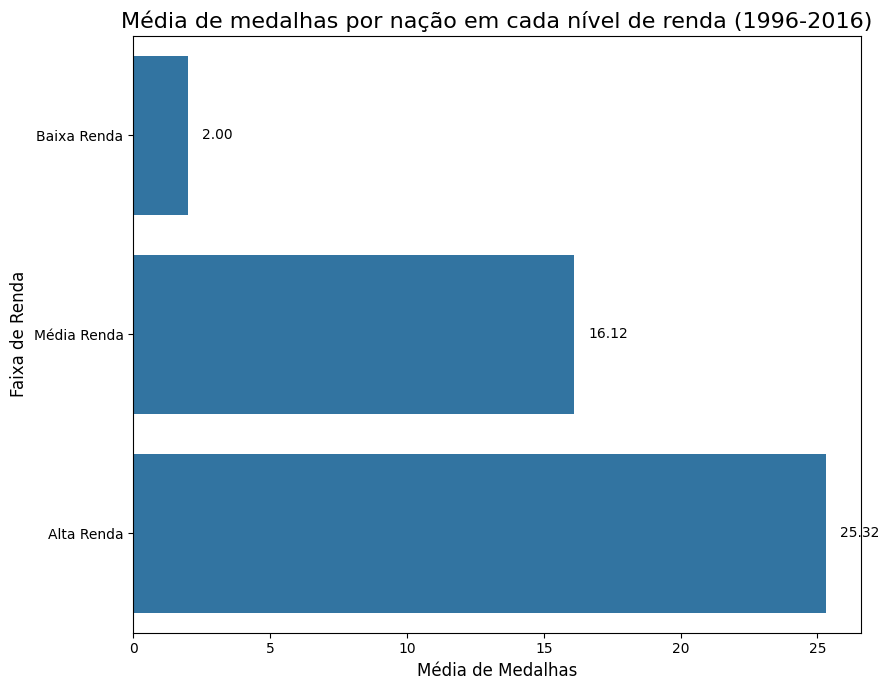

In [ ]:
vd = vd_original.copy()

# Agrupando por nível de renda e calculando a média de medalhas
medias = vd.groupby('nivel_renda')['total_medalhas'].mean().reset_index()

plt.figure(figsize=(9, 7))

# Definindo a ordem desejada
ordem = ['Baixa Renda', 'Média Renda', 'Alta Renda']

# Gráfico de barras com a média, ordenado
ax = sns.barplot(
    y='nivel_renda',
    x='total_medalhas',
    data=medias,
    orient='h',
    order=ordem
)

# Adiciona os valores exatos nas barras
for p in ax.patches:
    largura = p.get_width()
    y_posicao = p.get_y() + p.get_height() / 2
    ax.text(
        largura + 0.5,
        y_posicao,
        f'{largura:.2f}',
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

define_titulo_eixos('Média de medalhas por nação em cada nível de renda (1996-2016)',
                    'Média de Medalhas', 'Faixa de Renda')

finalizar_e_salvar_grafico("media_medalhas_fx_gpd.png")


O Gráfico de barras mostra que há uma diferença clara entre a média de medalhas ganhas entre as nações com gpd médio de baixa renda, média renda ou alta renda. Com uma ordenação evidente por nível de renda.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.



### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [ ]:
import pandas as pd

vd = vd_original.copy()

# Cria colunas acumuladas
vd['qtd_paises_acumulada'] = vd['qtd_paises'].cumsum()
vd['total_medalhas_acumulada'] = vd['total_medalhas'].cumsum()

# Estatísticas descritivas incluindo as novas colunas
desc = vd.drop(columns=['ano']).describe()

print(desc)


           media_gdp  total_medalhas  qtd_paises  qtd_paises_acumulada  \
count     723.000000      723.000000       723.0             723.00000   
mean    22214.929461       14.214385         1.0             362.00000   
std     24305.559134       35.965969         0.0             208.85641   
min       510.000000        0.000000         1.0               1.00000   
25%      4418.500000        0.000000         1.0             181.50000   
50%     12873.000000        1.000000         1.0             362.00000   
75%     34115.500000        8.000000         1.0             542.50000   
max    143830.000000      305.000000         1.0             723.00000   

       total_medalhas_acumulada  
count                723.000000  
mean                4819.650069  
std                 3205.488982  
min                    0.000000  
25%                 2098.000000  
50%                 4657.000000  
75%                 7818.000000  
max                10277.000000  


In [ ]:
print(f"Total de instâncias: {len(vd)}")
print("\nTipos de dados por coluna:")

print(vd.info())

Total de instâncias: 723

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 723 entries, 0 to 722
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ano             723 non-null    int64 
 1   delegacao       723 non-null    object
 2   nivel_renda     651 non-null    object
 3   media_gdp       723 non-null    int64 
 4   total_medalhas  723 non-null    int64 
 5   qtd_paises      723 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 34.0+ KB
None


###Média de GPD e Medalhas ao longo dos anos

Analisando como ocorre a média de gpd e medalhas ao longo dos anos para todas as nações, utilizando um gráfico de linhas.

Observe que há alguns casos de datas fora do "padrão". Esses casos serão tratados mais adiante na etapa de Pré-processamento de Dados.

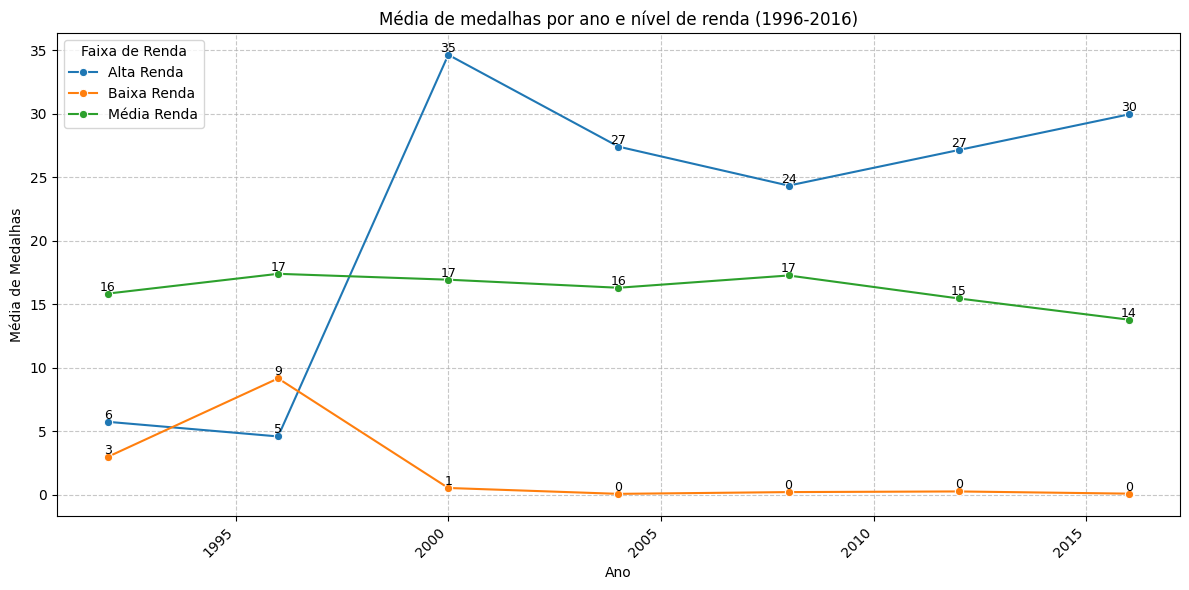

In [ ]:
# Calcula a média de medalhas por ano e nível de renda
average_medal_per_yearandgpd = (
    vd.groupby(['ano', 'nivel_renda'])[['total_medalhas']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

# Gráfico de linhas com três séries (uma por faixa de renda)
sns.lineplot(
    x='ano',
    y='total_medalhas',   # usa o nome correto da coluna
    hue='nivel_renda',    # separa as linhas por faixa de renda
    data=average_medal_per_yearandgpd,
    marker='o'
)

plt.title('Média de medalhas por ano e nível de renda (1996-2016)')
plt.xlabel('Ano')
plt.ylabel('Média de Medalhas')
plt.legend(title='Faixa de Renda')
plt.grid(True)

# Adicionando os valores sobre cada ponto, separados por grupo
for nivel, grupo in average_medal_per_yearandgpd.groupby('nivel_renda'):
    for _, row in grupo.iterrows():
        plt.text(
            x=row['ano'],
            y=row['total_medalhas'],
            s=f'{row["total_medalhas"]:.0f}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# Formatando o eixo X
ax = plt.gca()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

# Salvar gráfico
finalizar_e_salvar_grafico("media_medalhas_linha.png")

Tentando entender o motivo do aumento da média das medalhas das nações de alta renda, analizaremos as nações que estão no grupo

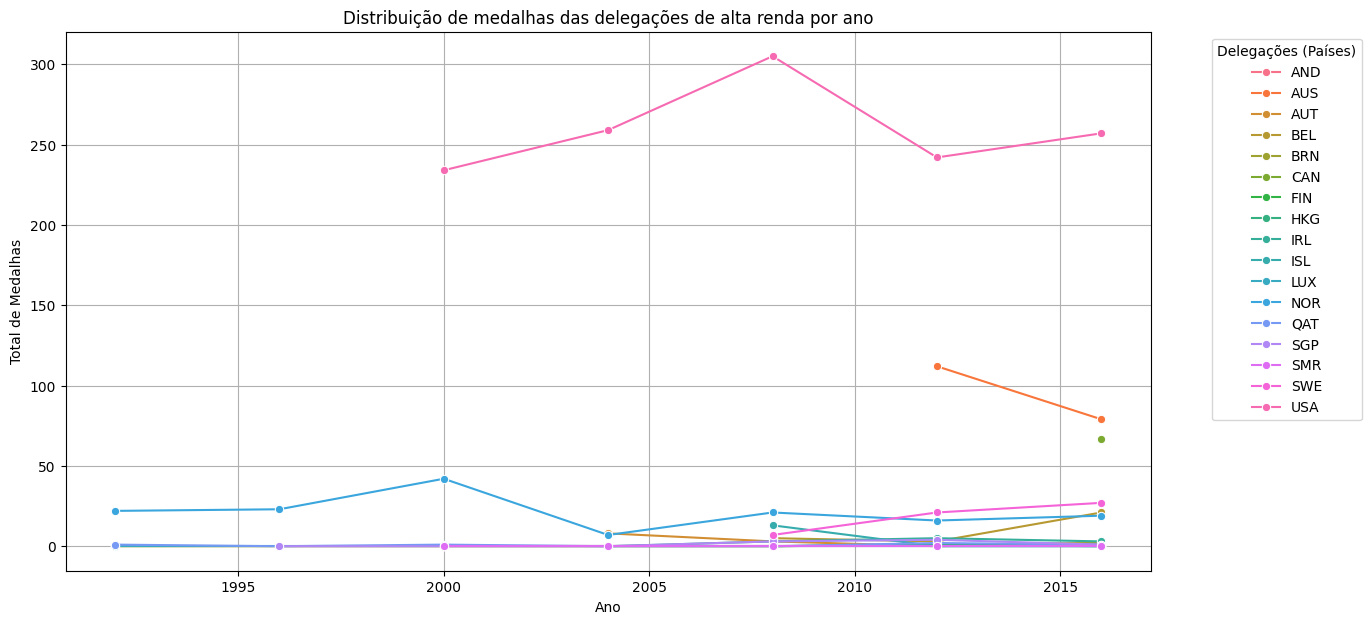

In [ ]:
# Filtra apenas as nações de alta renda
alta_renda = vd[vd['nivel_renda'] == 'Alta Renda']

plt.figure(figsize=(14, 7))

# Gráfico de linhas: cada país é uma linha
sns.lineplot(
    x='ano',
    y='total_medalhas',
    hue='delegacao',          # cada delegação vira uma linha
    data=alta_renda,
    marker='o'
)

plt.title('Distribuição de medalhas das delegações de alta renda por ano')
plt.xlabel('Ano')
plt.ylabel('Total de Medalhas')
plt.legend(title='Delegações (Países)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

A partir de 2000, o aumento da renda média da nação dos EUA os alça ao patamar de nação de alta renda. Dessa forma enviesando a evolução do ganho de medalhas do grupo de observação. Para a analise iremos retirar os EUA como outlier.

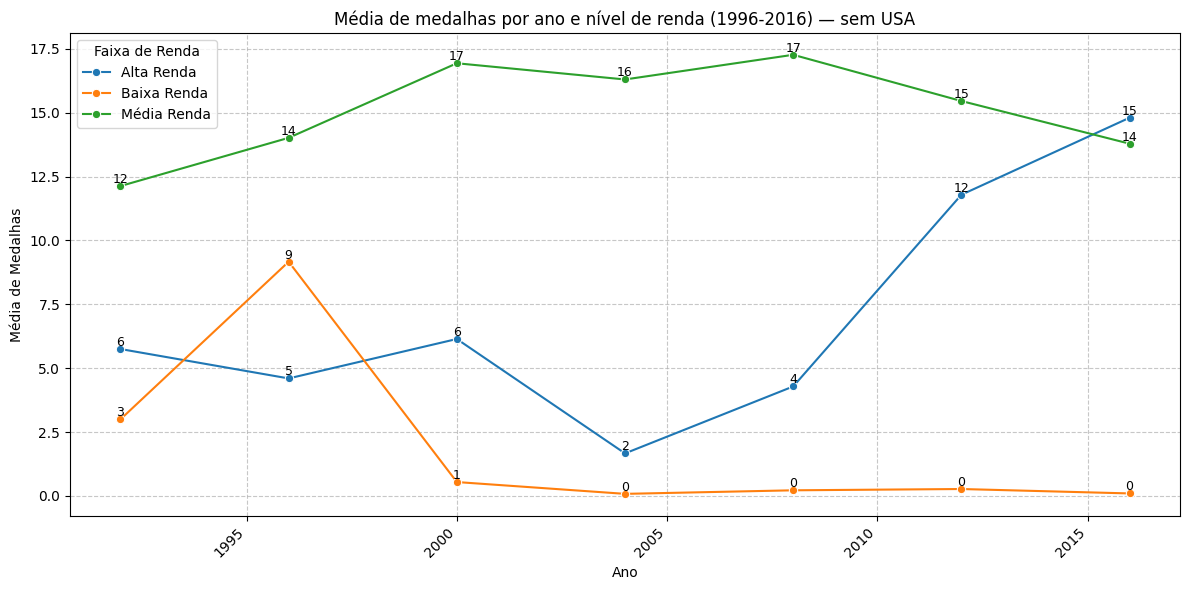

In [ ]:
# Remove os EUA da análise
vd_sem_usa = vd[vd['delegacao'] != 'USA']

# Calcula a média de medalhas por ano e nível de renda (sem USA)
average_medal_per_yearandgpd = (
    vd_sem_usa.groupby(['ano', 'nivel_renda'])[['total_medalhas']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

# Gráfico de linhas com três séries (uma por faixa de renda)
sns.lineplot(
    x='ano',
    y='total_medalhas',
    hue='nivel_renda',
    data=average_medal_per_yearandgpd,
    marker='o'
)

plt.title('Média de medalhas por ano e nível de renda (1996-2016) — sem USA')
plt.xlabel('Ano')
plt.ylabel('Média de Medalhas')
plt.legend(title='Faixa de Renda')
plt.grid(True)

# Adicionando os valores sobre cada ponto, separados por grupo
for nivel, grupo in average_medal_per_yearandgpd.groupby('nivel_renda'):
    for _, row in grupo.iterrows():
        plt.text(
            x=row['ano'],
            y=row['total_medalhas'],
            s=f'{row["total_medalhas"]:.0f}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# Formatando o eixo X
ax = plt.gca()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

# Salvar gráfico
finalizar_e_salvar_grafico("media_medalhas_linha_semUSA.png")

Analisando agora a evolução da média de gpd das nações por faixa para comparar com o gráfico acima:

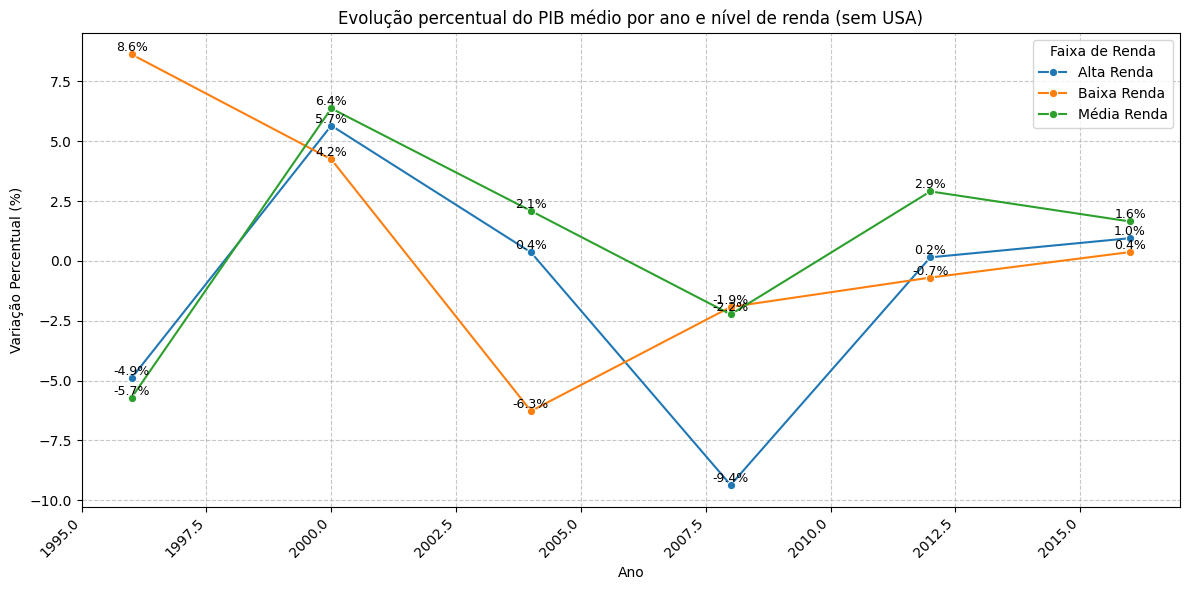

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove os EUA da análise
vd_sem_usa = vd[vd['delegacao'] != 'USA']

# Calcula o PIB médio por ano e nível de renda
gpd_medio_por_ano = (
    vd_sem_usa.groupby(['ano', 'nivel_renda'])[['media_gdp']]
    .mean()
    .reset_index()
)

# Calcula a variação percentual ano a ano
gpd_medio_por_ano['gpd_pct_change'] = (
    gpd_medio_por_ano.groupby('nivel_renda')['media_gdp'].pct_change() * 100
)

plt.figure(figsize=(12, 6))

# Gráfico de linhas mostrando evolução percentual
sns.lineplot(
    x='ano',
    y='gpd_pct_change',
    hue='nivel_renda',
    data=gpd_medio_por_ano,
    marker='o'
)

plt.title('Evolução percentual do PIB médio por ano e nível de renda (sem USA)')
plt.xlabel('Ano')
plt.ylabel('Variação Percentual (%)')
plt.legend(title='Faixa de Renda')
plt.grid(True)

# Adicionando os valores sobre cada ponto
for nivel, grupo in gpd_medio_por_ano.groupby('nivel_renda'):
    for _, row in grupo.iterrows():
        if not pd.isna(row['gpd_pct_change']):  # evita NaN no primeiro ano
            plt.text(
                x=row['ano'],
                y=row['gpd_pct_change'],
                s=f'{row["gpd_pct_change"]:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9,
                color='black'
            )

# Formatando o eixo X
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

# Salvar gráfico
finalizar_e_salvar_grafico("gpd_percentual_linha_semUSA.png")

Observando a imagem acima e comparando com a média de medalhas, notamos que não é possivel correlacionar a evolução vista no ganho de medalhas das nações de maior media de renda per capta com o aumento da renda percapta em si.

## Desvio Padrão
O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
vd.describe().loc['std']

,std
ano,7.792177
media_gdp,24305.559134
total_medalhas,35.965969
qtd_paises,0.000000
qtd_paises_acumulada,208.856410
total_medalhas_acumulada,3205.488982


## Análise das Hipóteses

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). Para visualizar e interpretar essas distribuições, utilizaremos ferramentas visuais fundamentais para representar essa distribuição, como o histograma, o barpot e o bloxplot.

Parte dessa analise foi feita anteriormente na analise exploratoria dos dados.
Inclusive em parte dos gráficos retirando os USA para melhor entendimento dos dados.

### *Hipótese 1: GDP x Medalhas*

Como o ganho de medalhas da nação está relacionado a renda percapta da mesma? Essa relação existe?
Na analise exploratória de dados, vimos que inicialmente existia alguma correlação. No entanto, posteriormente identificamos que os EUA concentram uma grande parcela das medalhas das nações de Alta Renda. Vamos fazer a mesma analise removendo os EUA do gráfico de barras.

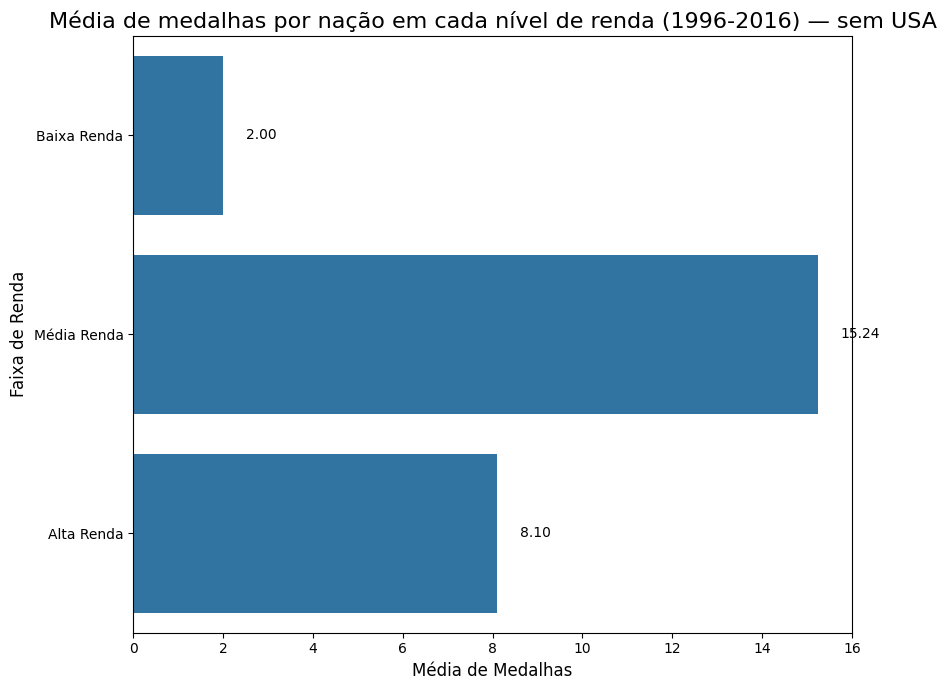

In [ ]:
vd = vd_original.copy()

# Remove os EUA da análise
vd_sem_usa = vd[vd['delegacao'] != 'USA']

# Agrupando por nível de renda e calculando a média de medalhas (sem USA)
medias = vd_sem_usa.groupby('nivel_renda')['total_medalhas'].mean().reset_index()

plt.figure(figsize=(9, 7))

# Definindo a ordem desejada
ordem = ['Baixa Renda', 'Média Renda', 'Alta Renda']

# Gráfico de barras com a média, ordenado
ax = sns.barplot(
    y='nivel_renda',
    x='total_medalhas',
    data=medias,
    orient='h',
    order=ordem
)

# Adiciona os valores exatos nas barras
for p in ax.patches:
    largura = p.get_width()
    y_posicao = p.get_y() + p.get_height() / 2
    ax.text(
        largura + 0.5,
        y_posicao,
        f'{largura:.2f}',
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

define_titulo_eixos(
    'Média de medalhas por nação em cada nível de renda (1996-2016) — sem USA',
    'Média de Medalhas',
    'Faixa de Renda'
)

finalizar_e_salvar_grafico("media_medalhas_fx_gpd_semUSA.png")

Retirando os EUA, não conseguimos correlacionar o nivel de renda percapto médio das nações e seu ganho esportivo olímpico entre 96 e 2016.


### *Hipótese 2: Variação de GPD por Faixa de ganhos de medalha*

O GPD Médio das nações varia de acordo com para as nações mais vitoriosas nos jogos olímpicos? Para isso vamos analisar a média da Renda per Capta por faixa de quantidade de medalhas e comparar em um gráfico de barras.


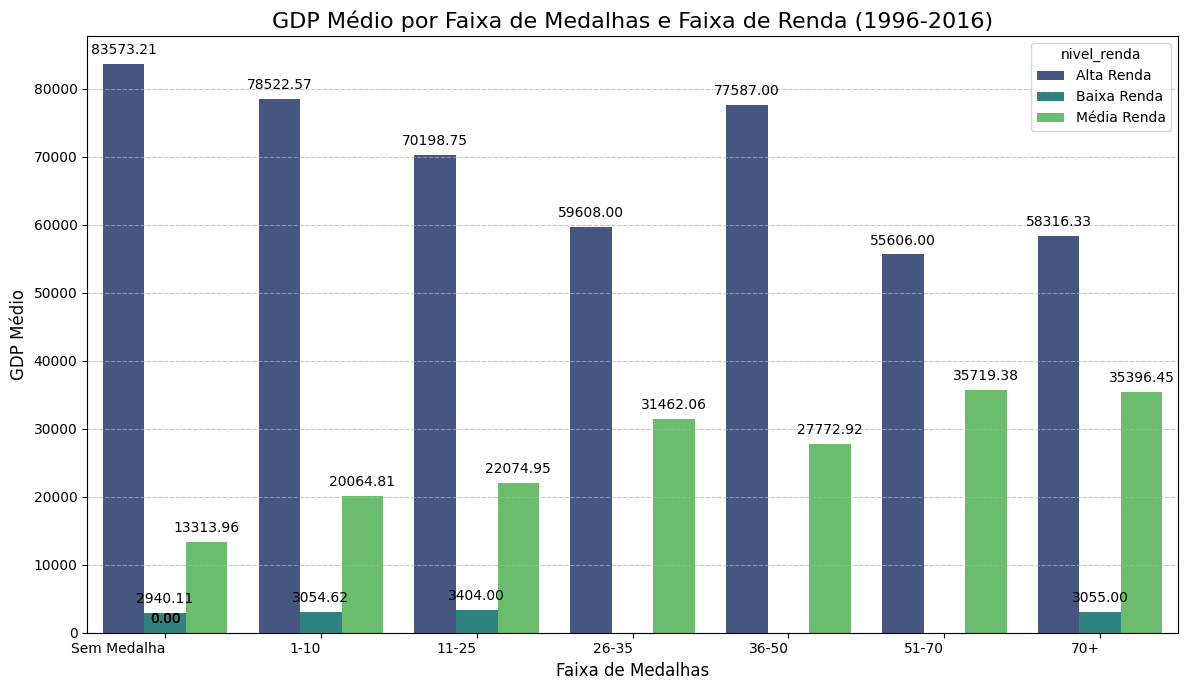

In [ ]:
vd = vd_original.copy()

# Capturando as Faixas de Medalhas definidas anteriormente
vd['faixa_medalhas'] = pd.cut(
    vd['total_medalhas'],
    bins=bins,          # intervalos de medalhas
    labels=labels,      # nomes das faixas
    right=False
)

# Calculando o GDP médio por Faixa de Medalhas e Faixa de Renda
gdp_medio_por_faixa = (
    vd.groupby(['faixa_medalhas', 'nivel_renda'], observed=True)['media_gdp']
    .mean()
    .reset_index()
)

gdp_medio_por_faixa.rename(
    columns={'media_gdp': 'gdp_medio_agrupado'}, inplace=True
)

# Gráfico de barras agrupadas (comparação entre faixas de renda dentro de cada faixa de medalhas)
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='faixa_medalhas',
    y='gdp_medio_agrupado',
    hue='nivel_renda',   # cada cor representa uma faixa de renda
    data=gdp_medio_por_faixa,
    palette='viridis'
)

# Títulos e rótulos
define_titulo_eixos(
    'GDP Médio por Faixa de Medalhas e Faixa de Renda (1996-2016)',
    'Faixa de Medalhas',
    'GDP Médio'
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0, ha='right')

# Adicionar os valores nas barras
for p in ax.patches:
    altura = p.get_height()
    if not pd.isna(altura):
        ax.annotate(
            f'{altura:.2f}',
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', va='center',
            xytext=(0, 10),
            textcoords='offset points'
        )

# Salvar gráfico
finalizar_e_salvar_grafico('gdp_medio_FaixaMedalhas_FaixaRenda_Barplot.png')

Para as nações de média renda, existe alguma relação entre a renda per capta da nação e o ganho esportivo, o mesmo não se pode dizer das outras faixas de nações. Para alta renda, aparentemente não há relação entre a renda per capta e o ganho esportivo, inclusive tendo uma correlação inversa entre os dois. Para as nações de baixa renda não há distinção identificavel.

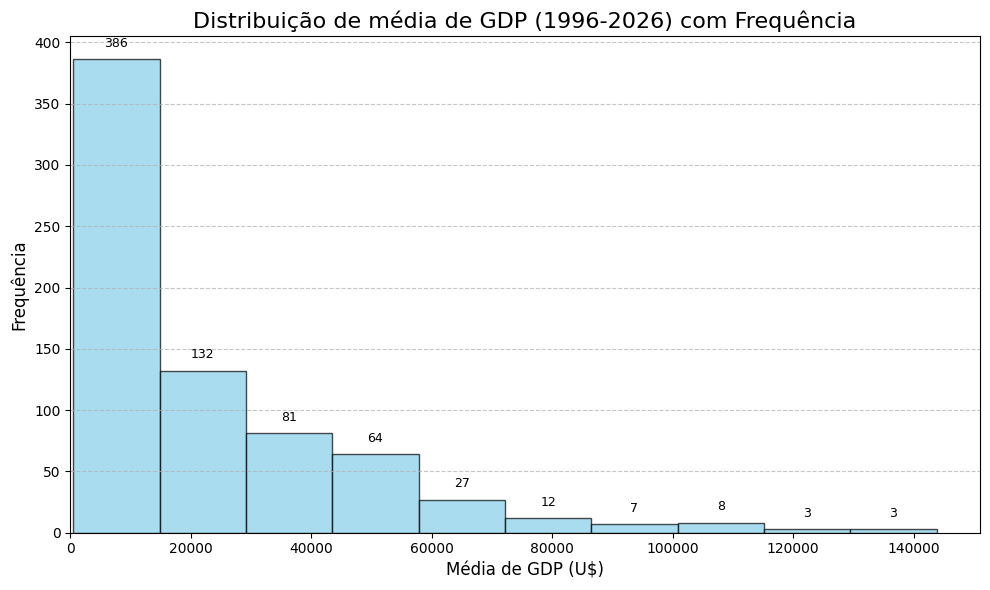

In [ ]:
plt.figure(figsize=(10, 6))

# Calculando o valor mínimo e máximo de media_gdp para definir os bins e o xlim
min_val = vd['media_gdp'].min()
max_val = vd['media_gdp'].max()

# Limites do eixo X
x_min_display = max(0, min_val - (max_val * 0.05))
x_max_display = max_val + (max_val * 0.05)

# Histograma da distribuição de media_gdp
n, bins, patches = plt.hist(
    vd['media_gdp'],
    bins=num_bins,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

# Títulos e rótulos
define_titulo_eixos(
    'Distribuição de média de GDP (1996-2026) com Frequência de medalhas',
    'Média de GDP (U$)',
    'Frequência'
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(x_min_display, x_max_display)

# Adicionar os valores nas barras
for i in range(len(patches)):
    patch = patches[i]
    height = patch.get_height()
    if height > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            height + (max(n) * 0.02),
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

# Salvar gráfico
finalizar_e_salvar_grafico('mediaGDP_Histograma.png')

O histograma em questão nos fornece insights valiosos sobre a distribuição de medalhas

A maior frequência de compras está claramente concentrada nas nações com GPD até 20k de dolares, ou seja, renda média.
Consequentemente, nações com renda per capta alta exibem frequências muito constantes, mas baixas.
Isso pode sugerir que o investimento esportivo de alto nível para essas nações não é algo de ordem institucional, mas sim oriundo de individuos da população.

## Hipótese 3: Ganhos de Medalha por região

Para investigar a existência de uma correlação entre o continente do mundo e o ganho de medalhas, observamos que estamos lidando com dois tipos de variáveis: a delegação, que pode ser tratado como uma variável categórica nominal, e a faixa de medalhas, que é uma variável categórica ordinal com uma ordem intrínseca definida.

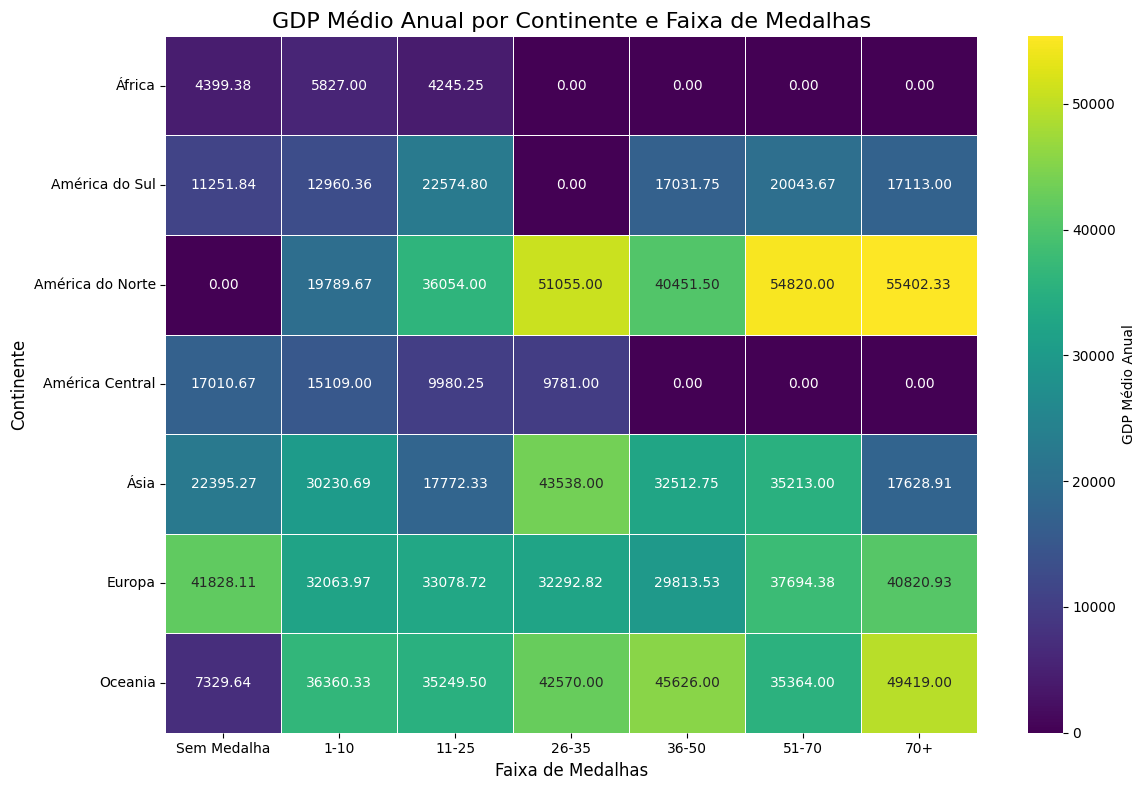

In [ ]:
vd = vd_original.copy()

# Definição dos bins e labels
bins = [0, 1, 10, 25, 35, 50, 70, 300]  # 7 intervalos
labels = ['Sem Medalha','1-10', '11-25', '26-35', '36-50', '51-70','70+']

# Captura das faixas de medalhas
vd['faixa_medalhas'] = pd.cut(
    vd['total_medalhas'],
    bins=bins,
    labels=labels,
    right=False,
    ordered=True
)

# Cria coluna de continente
vd['ioc_para_continente'] = vd['delegacao'].map(ioc_para_continente)

# Agrupando para obter o GDP médio anual por Continente e Faixa de Medalhas
gdp_por_continente_medalhas = (
    vd.groupby(['ioc_para_continente', 'faixa_medalhas'], observed=True)['media_gdp']
    .mean()   # aqui é média
    .unstack(fill_value=0)
)

# Reordena os continentes
ordem_continentes = ['África', 'América do Sul', 'América do Norte', 'América Central', 'Ásia', 'Europa', 'Oceania']
gdp_por_continente_medalhas = gdp_por_continente_medalhas.reindex(ordem_continentes)

# Plotando o heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    gdp_por_continente_medalhas,
    cmap='viridis',
    annot=True,
    fmt='.2f',   # duas casas decimais
    linewidths=.5,
    cbar_kws={'label': 'GDP Médio Anual'}
)

define_titulo_eixos(
    'GDP Médio Anual por Continente e Faixa de Medalhas',
    'Faixa de Medalhas',
    'Continente'
)

plt.yticks(rotation=0)
finalizar_e_salvar_grafico('heatmap_continente_faixa_medalhas_gdp_medio.png')


Se excluirmos as nações que não conquistam medalhas, exite uma progressão de GPD para as nações com maiores conquistas dentro da maioria dos contnentes. No entanto, vale observar que em geral as nações sem medalhas são as mais ricas de todos os continentes excluindo a Ásia.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

Nesse trabalho, buscamos **entender o comportamento esportivo das nações de acordo com a renda per capta da população**.

Selecionamos portanto como target o atributo "Total de medalhas". Trata-se de uma variável numérica contínua, representando o valor total de medalhas conquistadas, independente da "cor" da medalha.

E as features que podem influenciar a Quantidade Total:

*   **Delegaçao:** Delegação/País que disputou os jogos olímpicos.
*   **Faixa Renda:** Se a nação é considerada média, baixa ou alta renda de acordo com a renda per capta.

As features 'Quantidade de medalhas' e 'quantidade de paises' foram excluídas considerando serem um resultado direto do target, podendo futuramente influenciar o modelo e gerar vazamento de dados.


Definindo as Features (X) e Targets (y)
O Machine Learning Supervisionado (como a regressão para prever gastos neste caso) se baseia na ideia de que um modelo aprende a mapear entradas (features) para saídas desejadas (targets), usando exemplos onde a saída já é conhecida.

Features (X): São as variáveis independentes, os "ingredientes" que o modelo usará para fazer a previsão. Neste caso, são as colunas GPD e Continente.

Target (y): É a variável dependente, total de medalhas.

Sem essa distinção clara, o modelo não saberia o que ele deve aprender a prever a partir do quê.

In [ ]:
# Agrupando por continente e ano para calcular a média de GDP
X = (
    vd.groupby(['ioc_para_continente', 'ano'], observed=True)['media_gdp']
    .mean()
    .reset_index()   # transforma em DataFrame com colunas
)

# y = variável alvo
y = vd['total_medalhas']


## Codificação de variáveis categóricas

Para a codificação das variáveis categóricas escolhemos utilizar o One-Hot Encoding. Este método cria novas colunas binárias para cada categoria.

A função get_dummies da biblioteca Pandas é usada para converter variáveis categóricas em variáveis dummy (ou indicadoras). realizando a operação de One-Hot Encoding (Codificação One-Hot) no DataFrame X (que contém as features).

Esta etapa é importante pois possibilita compatibilidade com Modelos de Machine Learning uma vez que a grande maioria dos algoritmos de machine learning não consegue trabalhar diretamente com dados textuais ou categóricos no seu formato original. Eles esperam números. Assim, o One-Hot Encoding converte essas categorias em um formato numérico binário que os modelos podem processar e aprender.

Além disso, cada categoria se torna uma feature independente. Ou seja, ao criar colunas binárias, cada categoria é representada de forma "isolada" e não hierárquica.

In [ ]:
# Codificação One-Hot para features categóricas
X = pd.get_dummies(
    X,
    columns=['ioc_para_continente', 'ano'],  # colunas categóricas
    drop_first=True
)

## Divisão dos dados em treino e teste

Nesta etapa ocorre a divisão dos conjuntos em dados de treinamento e teste.


*   O conjunto de treinamento (X_train, y_train) é o que o modelo usa para aprender os padrões e ajustar seus parâmetros. Ele aprende com as features (X_train) a prever o target (y_train).
*   O conjunto de teste (X_test, y_test) é usado para avaliar o desempenho do modelo em dados que ele nunca viu antes. O modelo é alimentado apenas com as features de teste (X_test) e compara suas previsões com o y_test real.

Essa separação garante que haja uma avaliação honesta da capacidade de generalização do modelo, ou seja, quão bem ele realmente prevê novos gastos. Sem essa divisão, a avaliação seria irrealista.

In [ ]:
# Agrupando por continente e ano para calcular média de GDP e soma de medalhas
dados = (
    vd.groupby(['ioc_para_continente', 'ano'], observed=True)
    .agg(
        media_gdp=('media_gdp', 'mean'),
        total_amount=('total_medalhas', 'sum')
    )
    .reset_index()
)

# Features (X) e Target (y)
X = pd.get_dummies(
    dados[['ioc_para_continente', 'ano', 'media_gdp']],
    columns=['ioc_para_continente', 'ano'],
    drop_first=True
)
y = dados['total_amount']

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Dimensões")
print("Formato dos dados de TREINO (features):", X_train.shape)
print("Formato dos dados de TESTE (features):", X_test.shape)
print("Exemplo de X_train (features pré-processadas):")
display(X_train.head())
print("\nExemplo de y_train (target):")
display(y_train.head())

Dimensões
Formato dos dados de TREINO (features): (34, 13)
Formato dos dados de TESTE (features): (15, 13)
Exemplo de X_train (features pré-processadas):


,media_gdp,ioc_para_continente_América do Norte,ioc_para_continente_América do Sul,ioc_para_continente_Europa,ioc_para_continente_Oceania,ioc_para_continente_África,ioc_para_continente_Ásia,ano_1996,ano_2000,ano_2004,ano_2008,ano_2012,ano_2016
6,19751.600000,False,False,False,False,False,False,False,False,False,False,False,True
40,5168.772727,False,False,False,False,True,False,False,False,False,False,True,False
41,5505.304348,False,False,False,False,True,False,False,False,False,False,False,True
46,25333.636364,False,False,False,False,False,True,False,False,False,True,False,False
15,11648.875000,False,True,False,False,False,False,True,False,False,False,False,False



Exemplo de y_train (target):


,total_amount
6,31
40,25
41,29
46,342
15,82


Analisando cada parte:

1. Dimensões dos Dados
- Formato dos dados de treino (features): (34, 13)
- Formato dos dados de teste (features): (15, 13)
Havia um total de 49 amostras (registros agregados por continente e ano) no dataset após o pré-processamento.
Em seguida, dividimos os dados em conjuntos de treino e teste para que o modelo possa aprender com uma parte dos dados e ser avaliado em outra parte que ele "nunca viu" antes.
- 34 amostras (≈70% do total) foram usadas para treinar o modelo de Machine Learning.
- 15 amostras (≈30% do total) foram usadas para testar a performance do modelo.
13 colunas (features): Essa é a quantidade final de variáveis de entrada que o modelo receberá. O número aumentou em relação às colunas originais porque aplicamos One-Hot Encoding. Cada categoria em ioc_para_continente e em ano foi expandida em colunas binárias (True/False). Por exemplo, se havia 7 continentes e 6 anos distintos, cada um virou uma coluna dummy.

2. Exemplo de X_train (Features Pré-Processadas)
- media_gdp: variável numérica, representando a média do GDP por continente e ano.
- ioc_para_continente_África, Europa, Ásia, etc.: colunas binárias indicando o continente da delegação.
- ano_1996, ano_2000, ano_2004, etc.: colunas binárias indicando o ano da observação.
Os valores True/False (internamente 1/0) mostram que o One-Hot Encoding foi aplicado corretamente. Como utilizamos drop_first=True, a primeira categoria de cada variável foi removida para evitar multicolinearidade.

3. Exemplo de y_train (Target)
- total_amount: Este é o target, a variável que desejamos prever.
- Os valores (31, 25, 29, 342, 82, etc.) representam o total de medalhas agregadas por continente e ano.
dtype: int64: indica que os valores são números inteiros.


##Conclusão da etapa de Pré-processamento

Verificamos portanto que completamos com sucesso as etapas cruciais de pré-processamento de dados:

*   **Engenharia de features:** Extraímos informações valiosas da coluna 'GPD Media'.
*   **Codificação de variáveis categóricas:** Suas variáveis textuais/categóricas foram transformadas em um formato numérico que os algoritmos de ML podem processar, e a multicolinearidade foi endereçada com drop_first=True.
*   **Divisão em treino/teste:** Os dados estão prontos para que possamos treinar um modelo e avaliar sua performance em dados não vistos.
*   **Escalonamento de variáveis numéricas:** Não foi necessario escalonamento

O conjunto de dados X_train e y_train (e X_test, y_test) está agora em um formato pronto para ser usado para treinar um modelo de Machine Learning que preveja o ganho de medalhas de acordo com o GPD médio da nação/continente.

## Conclusão
A análise e pré-processamento do dataset Sale demonstra a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma análise clara das variáveis numéricas e categóricas.

As três hipóteses levantadas foram avaliadas:

Existe correlação entre a renda percapta da nação e suas conquistas olímpicas?
Sim, no entanto apenas se o País já tiver tradição olímpica, quanto mais incentivo histórico já existir, mais medalhas a renda per capta da nação tende a incentivar os ganhos esportivos.

Houve relação entre aumento de renda per capta no histórico e aumento de ganho de medalhas? Não, além do USA, considerado outlier, nenhuma nação teve aumento de Renda per Capta e demonstrou correlação posterior com o ganho esportivo.

**Dentro das regiões há distinção de Renda per capta** Os continentes são impactados pela diferença de renda per capta também? Constatamos que dentro de cada continente há impacto das maiores rendas per capta no ganho esportivo, excluindo as nações que já não possuem tradição olímpica (sem medalhas). Na África não vemos correlação e o continente deve ser tratado como dummie. Para essa hipóteses foram utilizados o Mapa de Calor.